#### Purpose of the Code

This Python script performs 3D clustering analysis on penguin measurement data using K-Means (or optionally Mean Shift) and visualizes the result in a 3D scatter plot.

It groups penguins based on culmen length, culmen depth, and flipper length, showing how these physical features relate and form natural clusters.

In [1]:
import numpy as np  # Numerical operations and arrays
import pandas as pd  # Data handling, reading CSV files, cleaning
import matplotlib.pyplot as plt  # Plotting library (MATLAB-style)
from matplotlib.colors import Normalize  # Used to normalize color scales

# Machine learning algorithms for clustering
from sklearn.cluster import KMeans, MeanShift


In [2]:
# Read the penguins dataset from a local folder
df = pd.read_csv('penguins_data.csv')
print(df.head(), '\n')


  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE   



In [3]:
# Drop any rows with missing values
df = df.dropna()
print(df.head(), '\n')


  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
4  Adelie  Torgersen              36.7             19.3              193.0   
5  Adelie  Torgersen              39.3             20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
4       3450.0  FEMALE  
5       3650.0    MALE   



In [4]:
# Select columns 2, 3, and 4 for clustering
# These correspond to: culmen_length_mm, culmen_depth_mm, and flipper_length_mm
X = df.iloc[:, [2, 3, 4]].values


In [5]:
# Construct the clustering model
model = KMeans(n_clusters=4, n_init='auto', random_state=5)
# model = MeanShift()  # Alternative option to detect clusters automatically

# Fit the model on the selected features
model.fit(X)


KMeans(n_clusters=4, random_state=5)

In [6]:
# Extract and print the centroids of the clusters
cluster_centers = model.cluster_centers_
centers = model.cluster_centers_
print('Centroids:', centers, '\n')


Centroids: [[ 38.43421053  18.00175439 187.        ]
 [ 46.37564103  15.18076923 211.97435897]
 [ 45.72333333  18.67222222 196.31111111]
 [ 49.61923077  15.66923077 223.44230769]] 



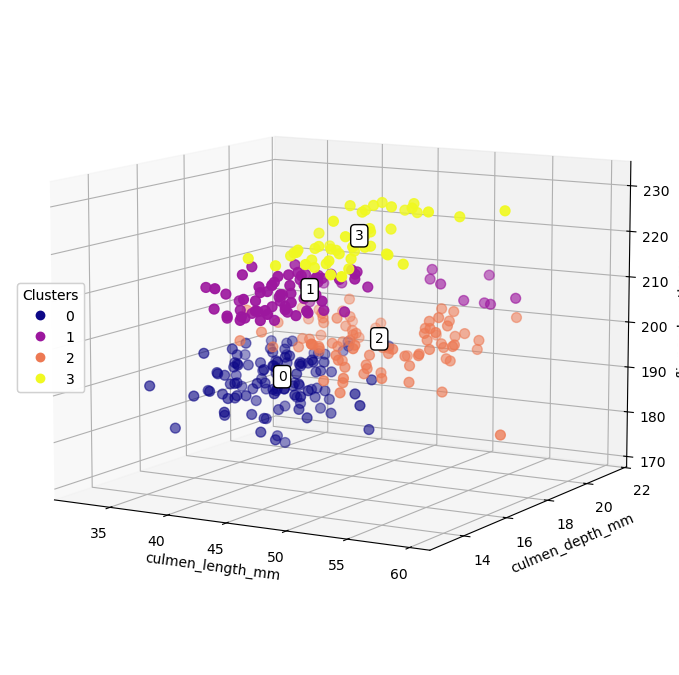

In [8]:
fig = plt.figure(figsize=(8,6))  # Create a new figure
ax = fig.add_subplot(111, projection='3d')  # Create a 3D axes object

# Normalize the color mapping for the number of clusters
nm = Normalize(vmin=0, vmax=len(centers)-1)

# Scatter plot of data points in 3D space, colored by predicted cluster
scatter1 = ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                      c=model.predict(X), s=50, cmap='plasma', norm=nm)

# Add cluster labels (numbers) next to each centroid
for i in range(centers.shape[0]):
    ax.text(centers[i, 0], centers[i, 1], centers[i, 2],
            str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Adjust the 3D viewing angle and distance for clarity
ax.azim = -60  # horizontal rotation
ax.dist = 10   # zoom distance
ax.elev = 10   # vertical angle

# Label the axes using the corresponding DataFrame column names
ax.set_xlabel(df.columns[2])
ax.set_ylabel(df.columns[3])
ax.set_zlabel(df.columns[4])

# Add a legend showing color → cluster mapping
legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="center left", title="Clusters")
ax.add_artist(legend1)

# Adjust layout and save the figure as a PNG image
fig.tight_layout(pad=-2.0)
#fig.savefig('cluster_3Dplot.png')


#### Interpretation of the 3D Plot
 - Each point = one penguin
 - Each color = one cluster (group of similar penguins)
 - Axes = beak and flipper measurements
 - Labeled centroids (0–3) = average position of each cluster

Clusters may roughly correspond to:
 - Different species (Adelie, Gentoo, Chinstrap)
 - Or sex differences (male/female body size variation)